# Q3 - IMDB Movie Reviews: Sentiment Analysis

## Settings — the only cell you edit on exam day

In [1]:
# ===================================================================
# EXAM DAY - CHANGE ONLY WHAT IS MARKED BELOW, THEN RUN ALL
# ===================================================================

CSV_FILE   = "Data_Q3.csv"   # <<< CHANGE - the file they give you
TEXT_COL   = "Review"        # <<< CHANGE - the column holding the text
LABEL_COL  = "Sentiment"     # <<< CHANGE - the column holding positive/negative
POS_LABEL  = "positive"      # <<< CHANGE - must match a value in LABEL_COL exactly
TEST_SIZE  = 0.30            # <<< CHANGE - 0.30 means 70% train / 30% test

MAX_FEATURES = 5000          # vocabulary size for the vectoriser
RANDOM_STATE = 42

# If you do not know the column names yet, run this first:
#     import pandas as pd; d = pd.read_csv(CSV_FILE); print(d.columns.tolist()); print(d.head())


## Step 1: Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)


## Step 2: Load the dataset

In [3]:
df = pd.read_csv(CSV_FILE)
df.head()


,Review,Sentiment
0,"One of the worst films I have seen, the acting...",negative
1,"A masterpiece of modern cinema, the cinematogr...",positive
2,"I regret watching this, the plot made no sense...",negative
3,"I regret watching this, the plot made no sense...",negative
4,"One of the worst films I have seen, the plot m...",negative


## Step 3: Explore the data

In [4]:
print("Shape:", df.shape)     # expect 2599 rows x 2 columns
df.info()


Shape: (2599, 2)
<class 'pandas.DataFrame'>
RangeIndex: 2599 entries, 0 to 2598
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Review     2599 non-null   str  
 1   Sentiment  2599 non-null   str  
dtypes: str(2)
memory usage: 265.1 KB


## Step 4: Prepare the text and the labels

In [5]:
# fillna("") guards against empty reviews, which would crash the vectoriser.
X = df[TEXT_COL].fillna("").astype(str)

# lower/strip cleans up label typos such as "Positive " vs "positive"
y = df[LABEL_COL].astype(str).str.lower().str.strip()

print(y.value_counts())


Sentiment
positive    1300
negative    1299
Name: count, dtype: int64


## Q3.1 Split into training (70%) and testing (30%) sets

In [6]:
# stratify=y keeps the positive/negative balance the same in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print("Training reviews:", len(X_train))
print("Testing reviews :", len(X_test))


Training reviews: 1819
Testing reviews : 780


## Q3.2 Convert text to numbers with TF-IDF

In [7]:
# TF-IDF = Term Frequency x Inverse Document Frequency.
# A word scores high when it appears often in ONE review but rarely across all
# reviews, so common words like "the" are automatically pushed down.
# stop_words="english" drops those filler words outright.
tfidf = TfidfVectorizer(stop_words="english", max_features=MAX_FEATURES)

X_train_vec = tfidf.fit_transform(X_train)   # fit on TRAIN only
X_test_vec  = tfidf.transform(X_test)        # then transform the test set

print("Number of features:", X_train_vec.shape[1])


Number of features: 84


## Q3.2 Alternative asked for in the question: CountVectorizer

In [8]:
# The question allows either method. CountVectorizer just counts words,
# without the inverse-document-frequency weighting.
count_vec = CountVectorizer(stop_words="english", max_features=MAX_FEATURES)
X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)

print("CountVectorizer features:", X_train_count.shape[1])


CountVectorizer features: 84


## Q3.3 Train the Logistic Regression model

In [9]:
# max_iter=1000 avoids the ConvergenceWarning on wide, sparse text data.
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print("Training complete.")


Training complete.


## Q3.4 Evaluate: Accuracy, Precision, Recall, F1-Score

In [10]:
# pos_label is required because the labels are words, not 0/1
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, pos_label=POS_LABEL, zero_division=0), 4))


Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## Q3.4 Full classification report

In [11]:
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       390
    positive       1.00      1.00      1.00       390

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780



## Q3.4 Confusion matrix

[[390   0]
 [  0 390]]


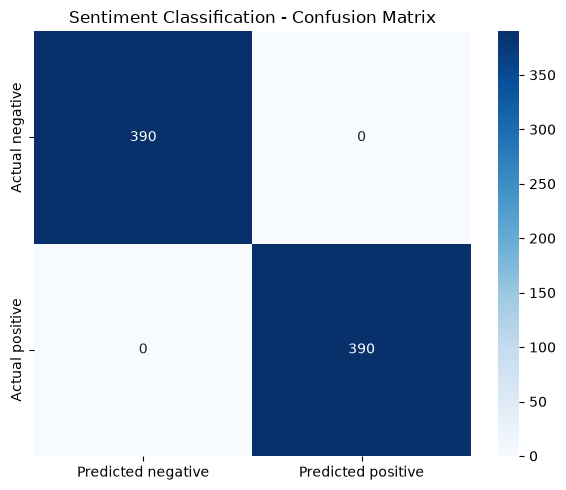

In [12]:
labels = sorted(y.unique())          # ['negative', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted " + l for l in labels],
            yticklabels=["Actual " + l for l in labels])
plt.title("Sentiment Classification - Confusion Matrix")
plt.tight_layout()
plt.show()


## Compare the two vectorisers

In [13]:
# Quick check of whether CountVectorizer does better or worse than TF-IDF
model_count = LogisticRegression(max_iter=1000)
model_count.fit(X_train_count, y_train)

print("TF-IDF accuracy          :", round(accuracy_score(y_test, y_pred), 4))
print("CountVectorizer accuracy :", round(accuracy_score(y_test, model_count.predict(X_test_count)), 4))


TF-IDF accuracy          : 1.0
CountVectorizer accuracy : 1.0


## Which words push a review positive or negative?

In [14]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefs = model.coef_[0]
order = np.argsort(coefs)

print("Most NEGATIVE words:", list(feature_names[order[:10]]))
print("Most POSITIVE words:", list(feature_names[order[-10:]]))


Most NEGATIVE words: ['avoid', 'bother', 'star', 'dull', 'lifeless', 'disappointed', 'sense', 'plot', 'cringeworthy', 'dialogue']
Most POSITIVE words: ['cinematography', 'gorgeous', 'beautiful', 'soundtrack', 'outstanding', 'performances', 'hooked', 'kept', 'watch', 'stars']


## Predict the sentiment of a new review

In [15]:
# A new review must go through transform() - never fit_transform()
new_reviews = [
    "Absolutely loved it, the acting was outstanding and the story moving.",
    "A complete waste of time, boring and badly written."
]

for review, prediction in zip(new_reviews, model.predict(tfidf.transform(new_reviews))):
    print(prediction.upper(), "->", review)


POSITIVE -> Absolutely loved it, the acting was outstanding and the story moving.
NEGATIVE -> A complete waste of time, boring and badly written.
